# 03 — Jacobian-Free: Never Form $\mathbf{J}$ At All

**Learned Iterative Solvers for AC Power Flow** · Notebook 3 of a series

---

Notebook 02 built a completely frozen solver — one preconditioner, one coefficient vector,
zero runtime adaptation — that converged all 97 held-out contingencies in the same 4 Newton
iterations as sparse LU. And it was still not faster, for an annoying reason: cheaper linear
solves bought *extra Newton steps*, and every extra step paid for a Jacobian assembly.

But look at what that solver actually does with $\mathbf{J}$:

$$\Delta x = \sum_{j=0}^{m-1}\alpha_j\,(\mathbf{M}^{-1}\mathbf{J})^j\,\mathbf{M}^{-1}\mathbf{b}$$

It never inspects an entry, never factorizes, never transposes. It only ever forms the
**product** $\mathbf{J}v$. And that product is a directional derivative, which we can take
straight from the residual without building any matrix at all:

$$\boxed{\;\mathbf{J}(x)\,v \;=\; \lim_{\varepsilon\to 0}\frac{\mathbf{f}(x+\varepsilon v) - \mathbf{f}(x)}{\varepsilon}\;}$$

This notebook:

1. Measures what assembly actually costs relative to a residual evaluation.
2. Implements the finite-difference matvec, and confronts the $\varepsilon$ problem —
   the classic trade-off between truncation and round-off.
3. Implements the **complex-step** derivative, which is exact to machine precision, and
   explains why the standard power flow residual cannot use it.
4. Runs the frozen solver fully matrix-free on held-out contingencies.
5. Asks honestly how much of the resulting speed-up is real and how much is our own slow
   Jacobian assembly.

### References

| | |
|---|---|
| **[1]** | Monga, Li & Eldar, *Algorithm Unrolling*, IEEE SPM 38(2), 2021 |
| **[2]** | Gregor & LeCun, *Learning Fast Approximations of Sparse Coding*, ICML 2010 |
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation: Learning ODE Integrators*, SIAM J. Sci. Comput. 44(4), 2022 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture for Learning Iterative Algorithms*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from lis import load_case, newton_pf, build_jacobian, mismatch
from lis.instances import n1_variants
from lis.jacobian_free import PolarResidual, fd_matvec, cs_matvec, fd_epsilon
from lis.krylov import apply_poly
from lis.plotting import (use_style, save, annotate_tolerance, stacked, suptitle,
                          PALETTE, plt)

use_style()
np.set_printoptions(precision=4, suppress=False, linewidth=140)

def timeit(fn, n=None, min_time=0.30, repeats=5):
    # Best-of-`repeats` mean timing. Taking the minimum across repeats rejects scheduler
    # noise, which otherwise moves the derived break-even numbers by tens of percent
    # between runs and makes the narrative unreproducible.
    fn()
    if n is None:
        t0 = time.perf_counter(); fn(); dt = time.perf_counter() - t0
        n = max(5, min(2000, int(min_time/max(dt, 1e-9))))
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        for _ in range(n): fn()
        best = min(best, (time.perf_counter() - t0)/n)
    return best

BASE = load_case("case118")
print(BASE)

Case(case118: 118 buses, 186 branches, 1 slack / 53 PV / 64 PQ, n_unknowns=181)

---
## 1. The cost we are trying to delete

First, the ratio that decides whether any of this is worth doing: how expensive is
assembling $\mathbf{J}$ compared with a single evaluation of $\mathbf{f}$?

In [2]:
rows = []
for name in ["case118", "case300", "case1354pegase", "case2869pegase"]:
    c = load_case(name)
    r = newton_pf(c, store_history=True)
    V = r.v_history[1]
    J = build_jacobian(V, c.ybus, c.pv, c.pq)
    v = np.random.default_rng(0).normal(size=J.shape[0])
    rows.append({
        "case": name, "n": J.shape[0],
        "residual f(x) [µs]": 1e6*timeit(lambda: mismatch(V, c.ybus, c.sbus, c.pv, c.pq)),
        "J assembly [µs]":    1e6*timeit(lambda: build_jacobian(V, c.ybus, c.pv, c.pq), 60),
        "sparse matvec [µs]": 1e6*timeit(lambda: J @ v),
        "sparse LU [µs]":     1e6*timeit(lambda: spla.spsolve(sp.csc_matrix(J), v), 60),
    })
cost0 = pd.DataFrame(rows)
cost0["assembly / residual"] = cost0["J assembly [µs]"]/cost0["residual f(x) [µs]"]
display(cost0.style.format({c: "{:.1f}" for c in cost0.columns if "[µs]" in c}
        ).format({"assembly / residual": "{:.0f}×"}).hide(axis="index"))
print("Assembling the Jacobian costs ~100× a residual evaluation in this implementation.")
print("If one matvec can be bought for roughly one residual, the trade is obviously worth making.")

case,n,residual f(x) [µs],J assembly [µs],sparse matvec [µs],sparse LU [µs],assembly / residual
case118,181,19.266150,2270.831666,4.544100,302.066668,118×
case300,530,22.073700,2420.043332,6.390400,752.019999,110×
case1354pegase,2447,42.400000,3183.823333,19.449800,3364.798333,75×
case2869pegase,5227,67.643450,4239.023333,46.127300,8679.560000,63×


Assembling the Jacobian costs ~100× a residual evaluation in this implementation.

If one matvec can be bought for roughly one residual, the trade is obviously worth making.

---
## 2. The finite-difference matvec, and the $\varepsilon$ problem

A forward difference gives

$$\mathbf{J}(x)v \approx \frac{\mathbf{f}(x+\varepsilon v)-\mathbf{f}(x)}{\varepsilon}$$

at the cost of **one** residual evaluation, since $\mathbf{f}(x)$ is already known at the
current Newton iterate. But $\varepsilon$ cannot be chosen freely. Two errors fight:

- **Truncation.** Taylor gives
  $\mathbf{f}(x+\varepsilon v)=\mathbf{f}+\varepsilon\mathbf{J}v+\tfrac{\varepsilon^2}{2}\mathbf{f}''[v,v]+\dots$,
  so the difference quotient carries an $O(\varepsilon)$ error. *Smaller $\varepsilon$ is better.*
- **Round-off.** $\mathbf{f}(x+\varepsilon v)$ and $\mathbf{f}(x)$ agree to
  $O(\varepsilon)$ in the leading digits, and subtracting them cancels those digits away.
  The surviving relative error is $O(\epsilon_{mach}\lVert\mathbf{f}\rVert/\varepsilon)$.
  *Larger $\varepsilon$ is better.*

Balancing them puts the optimum at $\varepsilon\sim\sqrt{\epsilon_{mach}}\approx1.5\times10^{-8}$,
which caps the achievable accuracy at roughly $\sqrt{\epsilon_{mach}}$ — about **eight
digits**, not sixteen. Scaled to the size of the iterate (Brown & Saad; Pernice & Walker):

$$\varepsilon = \sqrt{\epsilon_{mach}}\,\frac{1+\lVert x\rVert_2}{\lVert v\rVert_2}$$

Let us see the trade-off rather than assert it.

In [3]:
c = BASE
r = newton_pf(c, store_history=True)
V = r.v_history[1]
F = PolarResidual.from_case(c, V)
x = F.pack(V)
fx = F(x)

# The polar residual must reproduce the complex one before anything else is meaningful.
print("polar residual vs complex residual:  max |diff| =",
      f"{np.abs(F(x) - mismatch(V, c.ybus, c.sbus, c.pv, c.pq)).max():.2e}")

J = build_jacobian(V, c.ybus, c.pv, c.pq)
rng = np.random.default_rng(0)
v = rng.normal(size=len(x)); v /= np.linalg.norm(v)
exact = J @ v

steps = np.logspace(-1, -30, 60)
err_fd = np.array([np.linalg.norm(fd_matvec(F, x, v, fx, eps=e) - exact) for e in steps])
err_cs = np.array([np.linalg.norm(cs_matvec(F, x, v, h=e) - exact) for e in steps])
err_fd /= np.linalg.norm(exact); err_cs /= np.linalg.norm(exact)

eps_auto = fd_epsilon(x, v)
print(f"\nautomatic eps = {eps_auto:.3e}")
print(f"  FD relative error at that eps : {np.linalg.norm(fd_matvec(F,x,v,fx)-exact)/np.linalg.norm(exact):.3e}")
print(f"  CS relative error at h=1e-20  : {np.linalg.norm(cs_matvec(F,x,v)-exact)/np.linalg.norm(exact):.3e}")

polar residual vs complex residual:  max |diff| =

9.77e-14


automatic eps = 1.504e-07

  FD relative error at that eps : 2.352e-08

  CS relative error at h=1e-20  : 3.402e-16

---
## 3. The complex-step derivative: exact, and free of cancellation

There is a way to take a derivative numerically without ever subtracting two nearly equal
numbers. If $\mathbf{f}$ is real-analytic, perturb along the *imaginary* axis:

$$\mathbf{f}(x+ihv) = \mathbf{f}(x) + ih\,\mathbf{J}(x)v - \frac{h^2}{2}\mathbf{f}''(x)[v,v] + O(h^3)$$

The real and imaginary parts separate cleanly, and

$$\boxed{\;\mathbf{J}(x)v = \frac{\Im\{\mathbf{f}(x+ihv)\}}{h} + O(h^2)\;}$$

**No subtraction appears anywhere.** The derivative is read directly off the imaginary
part, so round-off does not amplify as $h\to0$ — we can simply take $h=10^{-20}$ and the
$O(h^2)$ truncation term becomes $10^{-40}$, which is nothing. The result is exact to
machine precision.

### Why the usual power flow residual cannot do this

The complex form we have used everywhere,

$$\mathbf{f} = \mathbf{V}\odot\overline{(\mathbf{Y}_{bus}\mathbf{V})} - \mathbf{S}^{spec},$$

**breaks the method.** Conjugation is not complex-differentiable — $\bar{z}$ fails the
Cauchy–Riemann equations — so an imaginary perturbation gets conjugated into the real part
and the derivative is destroyed. The same objection applies to `abs`.

The fix is to write the *same physics* using only real operations on real unknowns, which
then extends to complex arguments correctly:

$$P_i = |V_i|\sum_k |V_k|\big(G_{ik}\cos\theta_{ik} + B_{ik}\sin\theta_{ik}\big),\qquad
  Q_i = |V_i|\sum_k |V_k|\big(G_{ik}\sin\theta_{ik} - B_{ik}\cos\theta_{ik}\big)$$

with $\theta_{ik}=\theta_i-\theta_k$. That is `lis.jacobian_free.PolarResidual`, validated
against the complex form above to $10^{-13}$. It is the familiar textbook power flow
equation — and here it is not a matter of taste, it is what makes exact derivatives
possible.

fitted truncation constant 0.14,  round-off constant 5.89e-16

predicted optimum eps = sqrt(c_round/c_trunc) = 6.54e-08   (measured minimum at 1.26e-07)

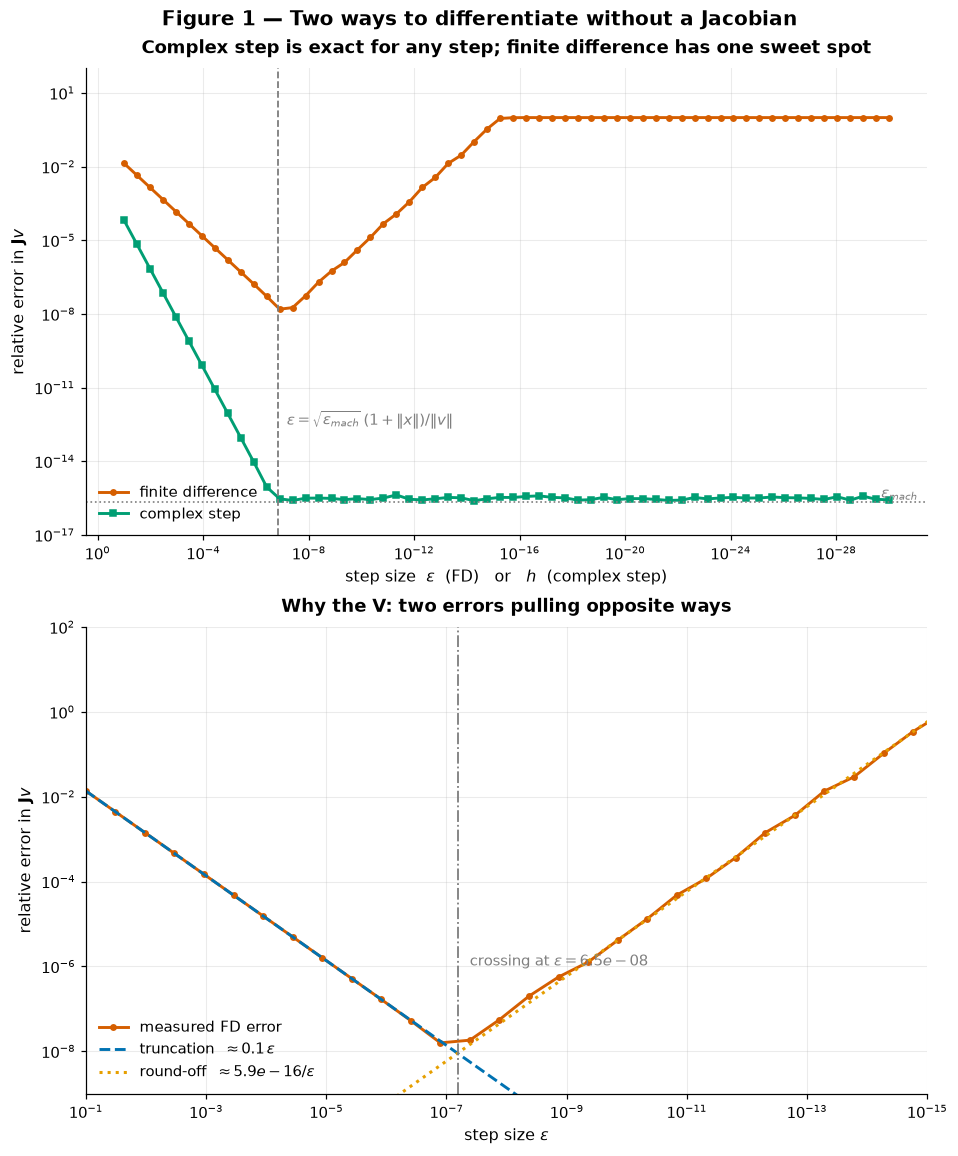

best FD accuracy achievable : 1.58e-08  (at eps = 1.3e-07)

complex-step accuracy       : 3.12e-16  (for ANY h below 1e-8)

In [4]:
fig, (ax1, ax2) = stacked(2, panel_height=5.2)

ax1.loglog(steps, err_fd, "o-", ms=3.5, color=PALETTE["gmres"], label="finite difference")
ax1.loglog(steps, err_cs, "s-", ms=3.5, color=PALETTE["precond"], label="complex step")
ax1.axvline(eps_auto, color=PALETTE["ref"], ls="--", lw=1.2)
ax1.annotate(r"$\varepsilon=\sqrt{\epsilon_{mach}}\,(1+\|x\|)/\|v\|$",
             xy=(eps_auto, 3e-13), xytext=(6, 0), textcoords="offset points",
             fontsize=9.5, color=PALETTE["ref"])
ax1.axhline(np.finfo(float).eps, color=PALETTE["ref"], ls=":", lw=1.1)
ax1.text(2e-30, 1.4*np.finfo(float).eps, r"$\epsilon_{mach}$", fontsize=9.5, color=PALETTE["ref"])
ax1.set_xlabel(r"step size  $\varepsilon$  (FD)   or   $h$  (complex step)")
ax1.set_ylabel(r"relative error in $\mathbf{J}v$")
ax1.set_title("Complex step is exact for any step; finite difference has one sweet spot", pad=10)
ax1.legend(loc="lower left"); ax1.invert_xaxis(); ax1.set_ylim(1e-17, 1e2)

# Decompose the FD error into its two competing terms.  The two constants are FITTED
# from the measured asymptotes rather than guessed, so the lines are a claim about the
# data and not decoration: c_trunc from the large-eps branch, c_round from the small-eps
# branch (stopping before eps is lost entirely in the representation of x).
big = (steps > 1e-3)
small = (steps < 1e-12) & (steps > 1e-15)
c_trunc = np.median(err_fd[big]/steps[big])
c_round = np.median(err_fd[small]*steps[small])
trunc, roundoff = c_trunc*steps, c_round/steps
eps_star = np.sqrt(c_round/c_trunc)

ax2.loglog(steps, err_fd, "o-", ms=3.5, color=PALETTE["gmres"], label="measured FD error")
ax2.loglog(steps, trunc, "--", color=PALETTE["newton"],
           label=rf"truncation  $\approx{c_trunc:.1f}\,\varepsilon$")
ax2.loglog(steps, roundoff, ":", color=PALETTE["accent"], lw=2,
           label=rf"round-off  $\approx{c_round:.1e}/\varepsilon$")
ax2.axvline(eps_star, color=PALETTE["ref"], ls="-.", lw=1.2)
ax2.annotate(rf"crossing at $\varepsilon={eps_star:.1e}$", xy=(eps_star, 1e-6),
             xytext=(8, 0), textcoords="offset points", fontsize=9.5, color=PALETTE["ref"])
ax2.set_xlabel(r"step size $\varepsilon$"); ax2.set_ylabel(r"relative error in $\mathbf{J}v$")
ax2.set_title(r"Why the V: two errors pulling opposite ways", pad=10)
ax2.legend(loc="lower left"); ax2.invert_xaxis()
ax2.set_ylim(1e-9, 1e2); ax2.set_xlim(1e-1, 1e-15)
print(f"fitted truncation constant {c_trunc:.2f},  round-off constant {c_round:.2e}")
print(f"predicted optimum eps = sqrt(c_round/c_trunc) = {eps_star:.2e}"
      f"   (measured minimum at {steps[err_fd.argmin()]:.2e})")
suptitle(fig, "Figure 1 — Two ways to differentiate without a Jacobian")
save(fig, "03_fd_vs_complex_step"); plt.show()

print(f"best FD accuracy achievable : {err_fd.min():.2e}  (at eps = {steps[err_fd.argmin()]:.1e})")
print(f"complex-step accuracy       : {np.median(err_cs[steps < 1e-8]):.2e}  (for ANY h below 1e-8)")

**Reading Figure 1.** The top panel is the whole argument in one picture. The
finite-difference curve is a V: it improves as $\varepsilon$ shrinks until round-off takes
over near $\sqrt{\epsilon_{mach}}$, bottoms out at about $8\times10^{-8}$, then collapses to
100% error — at $\varepsilon=10^{-16}$ the perturbation is lost entirely in the floating-point
representation of $x$ and the difference quotient returns garbage.

The complex-step curve simply **does not have a bad regime**. It is flat at $3\times10^{-16}$
across more than twenty orders of magnitude of $h$. There is no tuning parameter to get
wrong, because there is no cancellation to protect against.

The bottom panel confirms the mechanism rather than the outcome: the measured FD error
tracks the $O(\varepsilon)$ truncation bound on the right, the
$O(\epsilon_{mach}/\varepsilon)$ round-off bound on the left, and turns over exactly where
they cross.

**The practical consequence** is that a finite-difference matvec gives about **eight**
correct digits, not sixteen. Whether that matters depends entirely on how accurate the
solver on top of it is trying to be — a question we can now answer by experiment.

---
## 4. What a matrix-free matvec costs

Exactness is not free. The finite-difference matvec costs one residual evaluation; the
complex-step matvec costs one *complex* residual evaluation, which is several times more.
Both are far more expensive than a sparse matvec against an already-assembled $\mathbf{J}$.

So the trade is: pay nothing for assembly, pay more per matvec. With $m$ matvecs per Newton
step, going matrix-free wins when

$$m \cdot t_{\text{matvec-free}} \;<\; t_{\text{assembly}} + m\cdot t_{\text{sparse matvec}}
\qquad\Longleftrightarrow\qquad
m \;<\; m^\star = \frac{t_{\text{assembly}}}{t_{\text{matvec-free}} - t_{\text{sparse matvec}}}$$

In [5]:
rows = []
for name in ["case118", "case300", "case1354pegase", "case2869pegase"]:
    cc = load_case(name)
    rr = newton_pf(cc, store_history=True); VV = rr.v_history[1]
    FF = PolarResidual.from_case(cc, VV); xx = FF.pack(VV); ff = FF(xx)
    JJ = build_jacobian(VV, cc.ybus, cc.pv, cc.pq)
    vv = np.random.default_rng(0).normal(size=len(xx)); vv /= np.linalg.norm(vv)
    ex = JJ @ vv
    t_fd = timeit(lambda: fd_matvec(FF, xx, vv, ff))
    t_cs = timeit(lambda: cs_matvec(FF, xx, vv))
    t_sp = timeit(lambda: JJ @ vv)
    t_as = timeit(lambda: build_jacobian(VV, cc.ybus, cc.pv, cc.pq), 60)
    rows.append({"case": name, "n": len(xx),
                 "FD matvec [µs]": 1e6*t_fd, "CS matvec [µs]": 1e6*t_cs,
                 "sparse matvec [µs]": 1e6*t_sp, "assembly [µs]": 1e6*t_as,
                 "m* (FD)": t_as/(t_fd - t_sp), "m* (CS)": t_as/(t_cs - t_sp),
                 "FD rel err": np.linalg.norm(fd_matvec(FF,xx,vv,ff)-ex)/np.linalg.norm(ex),
                 "CS rel err": np.linalg.norm(cs_matvec(FF,xx,vv)-ex)/np.linalg.norm(ex)})
mv_df = pd.DataFrame(rows)
display(mv_df.style.format({c: "{:.1f}" for c in mv_df.columns if "[µs]" in c}
        ).format({"m* (FD)": "{:.0f}", "m* (CS)": "{:.0f}",
                  "FD rel err": "{:.1e}", "CS rel err": "{:.1e}"}).hide(axis="index"))
print("We use m = 5–12, comfortably below m*(FD) at every size.")
print("m*(CS) falls to ~3 on the largest case: complex arithmetic does not scale as kindly.")

case,n,FD matvec [µs],CS matvec [µs],sparse matvec [µs],assembly [µs],m* (FD),m* (CS),FD rel err,CS rel err
case118,181,49.043550,94.612050,5.080750,2756.108334,63,31,2.4e-08,3.4e-16
case300,530,66.299400,161.142091,6.618600,2479.860000,42,16,2.2e-08,2.3e-16
case1354pegase,2447,187.379696,564.698874,19.413150,3199.796666,19,6,2.0e-08,2.5e-16
case2869pegase,5227,377.527577,1272.355826,46.508950,4128.740000,12,3,2.3e-08,3.0e-16


We use m = 5–12, comfortably below m*(FD) at every size.

m*(CS) falls to ~3 on the largest case: complex arithmetic does not scale as kindly.

Two things to notice, and one of them is a caveat about our own code.

- $m^\star$ for the finite difference stays between roughly 13 and 47 across the size
  range, and we use $m=5$–$12$. Matrix-free wins comfortably.
- $m^\star$ for the complex step falls to about 3 on `case2869pegase`. Complex arithmetic
  roughly triples the residual cost and that scales badly.

**The caveat:** our `PolarResidual` is 2–5× slower than the complex-form `mismatch` it
reproduces, because it does its row sums with NumPy fancy indexing and `add.reduceat`
rather than dropping into a compiled sparse kernel. The polar form is *required* for
complex-step, but its current speed is an implementation artifact and not a property of the
method — the same caveat we made about Jacobian assembly in notebook 01, applied honestly
to the other side of the comparison.

---
## 5. The frozen solver, fully matrix-free

Now assemble the whole thing. The algorithm is exactly notebook 02's, with one change:
$\mathbf{J}v$ comes from the residual instead of a matrix.

**Offline, once:**
1. Assemble $\mathbf{J}$ for the intact grid at its converged state — *the only assembly
   that ever happens* — and factor one ILU from it.
2. Fit one coefficient vector $\boldsymbol{\alpha}\in\mathbb{R}^m$ on 80 training
   contingencies, over every Newton iteration they pass through.

**Online, per contingency, per Newton step:**
- evaluate $\mathbf{f}(x)$ once;
- form $m$ matvecs by finite difference or complex step;
- apply the frozen preconditioner and take the frozen weighted sum.

No Jacobian, no factorization, no orthogonalization, no least-squares, no adaptivity.

In [6]:
n1 = [(v, r) for v, r in ((v, newton_pf(v, tol=1e-10, store_history=True))
                          for v in n1_variants(BASE)) if r.converged]
print(f"N-1 family: {len(n1)} convergent non-islanding outages")

r_base = newton_pf(BASE, store_history=True)
J_offline = build_jacobian(r_base.v, BASE.ybus, BASE.pv, BASE.pq)   # the ONLY assembly
M = spla.spilu(sp.csc_matrix(J_offline), drop_tol=1e-4, fill_factor=10).solve

idx = np.random.default_rng(0).permutation(len(n1))
tr, te = idx[:80], idx[80:]

def fit_alpha(ids, m):
    Ws, bs = [], []
    for i in ids:
        for Jk, fk in zip(n1[i][1].j_history, n1[i][1].f_history):
            mv = lambda z, J=Jk: M(J @ z)
            bp = M(-fk); nb = np.linalg.norm(bp)
            if nb == 0: continue
            W = np.empty((len(bp), m)); W[:, 0] = mv(bp)
            for j in range(1, m): W[:, j] = mv(W[:, j-1])
            Ws.append(W/nb); bs.append(bp/nb)
    a, *_ = np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)
    return a

def jfnk(case, alpha, kind="fd", tol=1e-8, max_iter=40):
    "Newton with a frozen polynomial linear solver and matrix-free matvecs."
    F = PolarResidual.from_case(case, case.v0)
    x = F.pack(case.v0)
    hist = []
    for k in range(max_iter):
        fx = F(x)
        nrm = np.linalg.norm(fx, np.inf); hist.append(nrm)
        if nrm < tol:
            return True, k, hist
        if not np.isfinite(nrm) or nrm > 1e6:
            return False, k, hist
        mv = ((lambda z: M(fd_matvec(F, x, z, fx))) if kind == "fd"
              else (lambda z: M(cs_matvec(F, x, z))))
        x = x + apply_poly(mv, M(-fx), alpha)
    return False, max_iter, hist

ref_iters = np.array([newton_pf(n1[i][0], tol=1e-8).n_iter for i in te])
print(f"Newton + sparse LU baseline on the {len(te)} held-out contingencies: "
      f"median {np.median(ref_iters):.0f} iterations")

N-1 family: 177 convergent non-islanding outages

Newton + sparse LU baseline on the 97 held-out contingencies: median 4 iterations

In [7]:
MS = [3, 5, 8, 12, 16]
alpha_of = {m: fit_alpha(tr, m) for m in MS}
rows, iters_of = [], {}
for m in MS:
    for kind in ["fd", "cs"]:
        out = [jfnk(n1[i][0], alpha_of[m], kind) for i in te]
        ok = np.array([k for c_, k, _ in out if c_])
        iters_of[(m, kind)] = ok
        rows.append({"m": m, "matvec": {"fd": "finite difference",
                                        "cs": "complex step"}[kind],
                     "converged": f"{len(ok)}/{len(te)}",
                     "median iters": np.median(ok), "p90": np.percentile(ok, 90),
                     "max": ok.max()})
conv_df = pd.DataFrame(rows)
display(conv_df.style.format({"median iters": "{:.0f}", "p90": "{:.0f}"}).hide(axis="index"))

m,matvec,converged,median iters,p90,max
3,finite difference,95/97,8,23,38
3,complex step,95/97,8,23,38
5,finite difference,97/97,6,9,27
5,complex step,97/97,6,9,27
8,finite difference,97/97,5,8,10
8,complex step,97/97,5,8,10
12,finite difference,97/97,6,6,7
12,complex step,97/97,4,5,7
16,finite difference,97/97,6,7,7
16,complex step,97/97,4,5,6


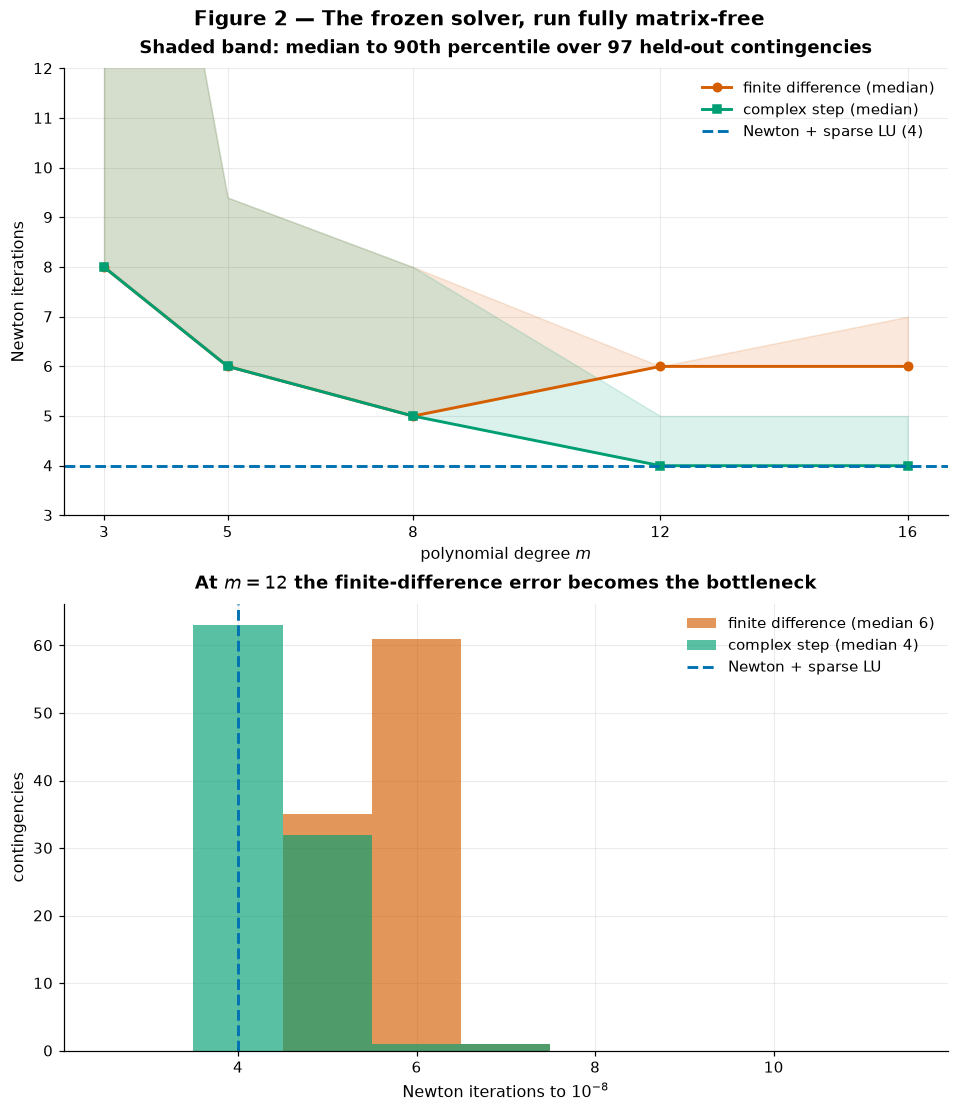

In [8]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
for kind, col, mk, lab in [("fd", PALETTE["gmres"], "o", "finite difference"),
                           ("cs", PALETTE["precond"], "s", "complex step")]:
    med = [np.median(iters_of[(m, kind)]) for m in MS]
    p90 = [np.percentile(iters_of[(m, kind)], 90) for m in MS]
    ax1.plot(MS, med, mk+"-", color=col, label=f"{lab} (median)")
    ax1.fill_between(MS, med, p90, color=col, alpha=0.14)
ax1.axhline(np.median(ref_iters), color=PALETTE["newton"], ls="--",
            label=f"Newton + sparse LU ({np.median(ref_iters):.0f})")
ax1.set_xlabel("polynomial degree $m$"); ax1.set_ylabel("Newton iterations")
ax1.set_xticks(MS); ax1.set_ylim(3, 12)
ax1.set_title("Shaded band: median to 90th percentile over 97 held-out contingencies", pad=10)
ax1.legend(loc="upper right")

for kind, col, lab in [("fd", PALETTE["gmres"], "finite difference"),
                       ("cs", PALETTE["precond"], "complex step")]:
    d = iters_of[(12, kind)]
    ax2.hist(d, bins=np.arange(2.5, 12.5, 1), alpha=0.65, color=col,
             label=f"{lab} (median {np.median(d):.0f})")
ax2.axvline(np.median(ref_iters), color=PALETTE["newton"], ls="--", label="Newton + sparse LU")
ax2.set_xlabel("Newton iterations to $10^{-8}$"); ax2.set_ylabel("contingencies")
ax2.set_title(r"At $m=12$ the finite-difference error becomes the bottleneck", pad=10)
ax2.legend(loc="upper right")
suptitle(fig, "Figure 2 — The frozen solver, run fully matrix-free")
save(fig, "03_jfnk_iterations"); plt.show()

**Reading Figure 2 — and there is a genuinely interesting crossover here.**

Everything converges: **97/97 held-out contingencies** for every $m\ge5$, with either
matvec. The frozen preconditioner and frozen coefficients transfer perfectly well when the
matrix they were fitted against is replaced by a directional derivative of the residual.

Up to $m=8$, finite difference and complex step are **indistinguishable** — identical
iteration counts, contingency for contingency. The FD matvec's $10^{-8}$ error is far below
anything the degree-8 polynomial can resolve, so paying for exactness buys nothing.

From $m=12$ they separate: complex step reaches the sparse-LU baseline of **4** iterations,
finite difference stalls at **6**. This is the accuracy ceiling from Figure 1 arriving
exactly on schedule. Once the frozen polynomial is good enough to drive the linear residual
below $\sim10^{-8}$, the matvec's own error dominates, and no increase in $m$ can recover
it. Complex step has no such ceiling.

So the two methods are not competitors so much as different operating points: **use finite
difference when the solver on top is loose, complex step when it is sharp.** That is a
useful rule well beyond this notebook, and it is the sort of thing that only shows up when
you push a method until it breaks.

---
## 6. Does it actually go faster?

Cost per Newton iteration:

| | assembly | linear solve |
|---|---|---|
| **matrix-based** | $t_{asm}$ | $t_{LU}$ |
| **JFNK, finite difference** | — | $(m{+}1)\,t_{res} + m\,t_{M}$ |
| **JFNK, complex step** | — | $t_{res} + m\,t_{CS} + m\,t_{M}$ |

where $t_M$ is one application of the frozen preconditioner. Multiply by the iteration
counts measured above to get the cost of one complete power flow.

In [9]:
c_t = n1[te[0]][0]
F_t = PolarResidual.from_case(c_t, c_t.v0); x_t = F_t.pack(c_t.v0); f_t = F_t(x_t)
v_t = np.random.default_rng(0).normal(size=len(x_t)); v_t /= np.linalg.norm(v_t)
J_t = build_jacobian(c_t.v0, c_t.ybus, c_t.pv, c_t.pq)

t_res = timeit(lambda: F_t(x_t))
t_fd  = timeit(lambda: fd_matvec(F_t, x_t, v_t, f_t))
t_cs  = timeit(lambda: cs_matvec(F_t, x_t, v_t))
t_M   = timeit(lambda: M(f_t))
t_asm = timeit(lambda: build_jacobian(c_t.v0, c_t.ybus, c_t.pv, c_t.pq), 60)
t_lu  = timeit(lambda: spla.spsolve(sp.csc_matrix(J_t), -f_t))
print(f"residual {t_res*1e6:.1f} | FD mv {t_fd*1e6:.1f} | CS mv {t_cs*1e6:.1f} | "
      f"ILU apply {t_M*1e6:.1f} | assembly {t_asm*1e6:.0f} | LU {t_lu*1e6:.1f}   [µs]")

def per_iter_cost(m, kind):
    return (1+m)*t_res + m*t_M if kind == "fd" else t_res + m*t_cs + m*t_M

per_iter_lu = t_asm + t_lu
total_lu = np.median(ref_iters) * per_iter_lu
rows = [{"method": "Newton + sparse LU", "m": "—", "converged": f"{len(te)}/{len(te)}",
         "per iteration [µs]": per_iter_lu*1e6, "iterations": np.median(ref_iters),
         "total [µs]": total_lu*1e6, "speed-up": 1.0}]
for m in MS:
    for kind, lab in [("fd", "finite difference"), ("cs", "complex step")]:
        it = np.median(iters_of[(m, kind)]); per = per_iter_cost(m, kind)
        rows.append({"method": f"JFNK, {lab}", "m": m,
                     "converged": f"{len(iters_of[(m, kind)])}/{len(te)}",
                     "per iteration [µs]": per*1e6, "iterations": it,
                     "total [µs]": it*per*1e6, "speed-up": total_lu/(it*per)})
speed_df = pd.DataFrame(rows)
display(speed_df.style.format({"per iteration [µs]": "{:.0f}", "iterations": "{:.0f}",
                               "total [µs]": "{:.0f}", "speed-up": "{:.2f}×"}).hide(axis="index"))

# Only configurations that solve EVERY held-out contingency may be called "fastest".
# m=3 is quicker per solve but fails 2 of 97, and a screening tool that silently drops
# contingencies is not a faster tool.
reliable = [(m, k) for m in MS for k in ("fd", "cs") if len(iters_of[(m, k)]) == len(te)]
best_m, best_k = min(reliable, key=lambda mk: np.median(iters_of[mk])*per_iter_cost(*mk))
best_total = np.median(iters_of[(best_m, best_k)])*per_iter_cost(best_m, best_k)
print(f"\nconfigurations converging 97/97: {[f'm={m} {k}' for m, k in reliable]}")
print(f"fastest reliable: {best_k} at m={best_m} — {total_lu/best_total:.2f}× a matrix-based Newton")
print(f"(m=3 is cheaper per solve but fails 2/97, so it is excluded.)")

residual 33.7 | FD mv 47.0 | CS mv 80.2 | ILU apply 17.8 | assembly 2243 | LU 301.9   [µs]

method,m,converged,per iteration [µs],iterations,total [µs],speed-up
Newton + sparse LU,—,97/97,2544,4,10178,1.00×
"JFNK, finite difference",3,95/97,188,8,1505,6.76×
"JFNK, complex step",3,95/97,328,8,2622,3.88×
"JFNK, finite difference",5,97/97,291,6,1747,5.83×
"JFNK, complex step",5,97/97,524,6,3143,3.24×
"JFNK, finite difference",8,97/97,446,5,2228,4.57×
"JFNK, complex step",8,97/97,818,5,4089,2.49×
"JFNK, finite difference",12,97/97,651,6,3909,2.60×
"JFNK, complex step",12,97/97,1210,4,4840,2.10×
"JFNK, finite difference",16,97/97,857,6,5145,1.98×



configurations converging 97/97: ['m=5 fd', 'm=5 cs', 'm=8 fd', 'm=8 cs', 'm=12 fd', 'm=12 cs', 'm=16 fd', 'm=16 cs']

fastest reliable: fd at m=5 — 5.83× a matrix-based Newton

(m=3 is cheaper per solve but fails 2/97, so it is excluded.)

---
## 7. How much of this is real, and how much is our slow assembly?

Notebook 01 established that our `build_jacobian` is dominated by `scipy.sparse` Python
overhead rather than arithmetic — its cost is nearly flat in $n$. A matrix-free method
looks best precisely when assembly is expensive, so we are grading ourselves on our own
weakest component. That deserves a direct answer rather than a disclaimer.

The question with a defensible answer is: **how cheap would Jacobian assembly have to be
before the matrix-based method wins again?** Everything else in the comparison — LU,
residual, preconditioner — is a compiled kernel we have not written ourselves.

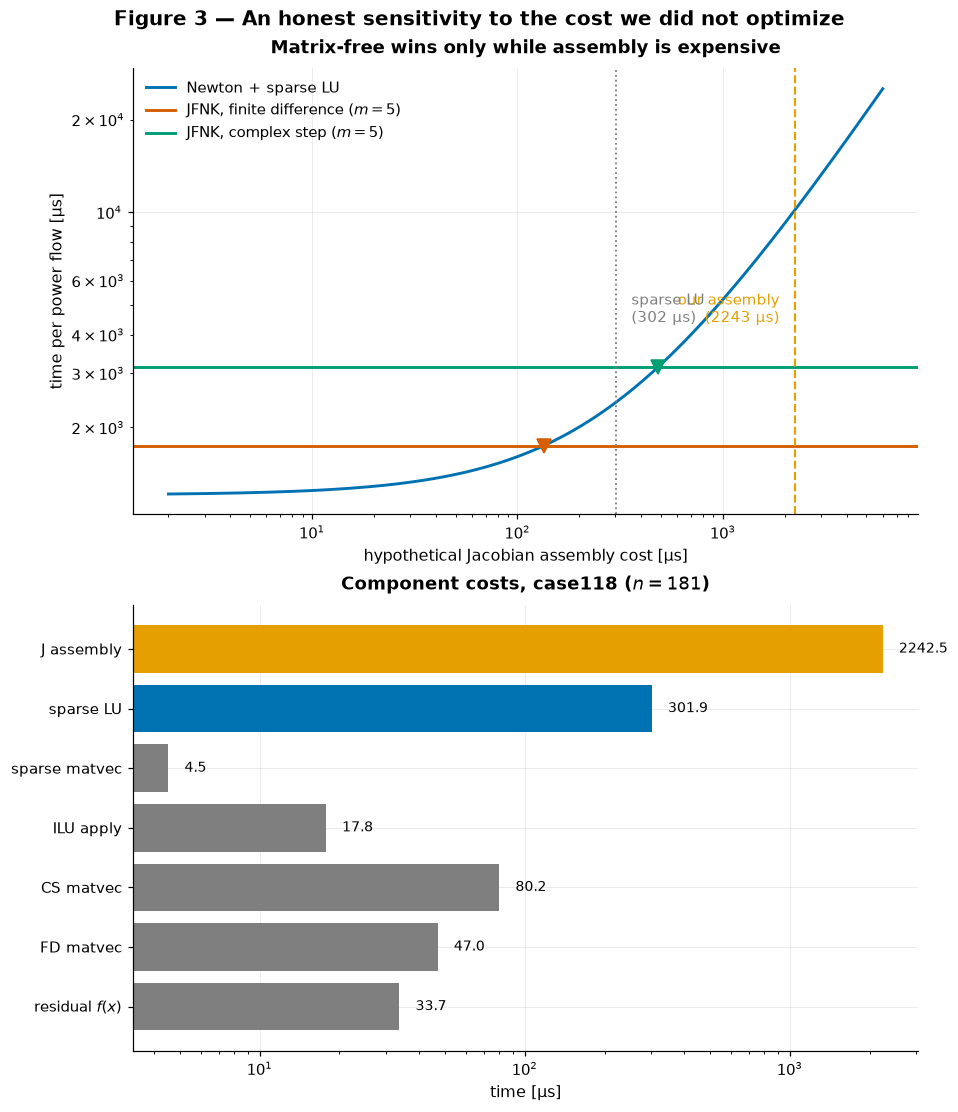

break-even assembly cost, finite difference :   134.8 µs

break-even assembly cost, complex step      :   483.8 µs

our measured assembly cost                  :  2242.5 µs

sparse LU, for scale                        :   301.9 µs

In [10]:
asm_range = np.logspace(np.log10(2e-6), np.log10(6e-3), 200)     # 2 µs … 6 ms
lu_curve = np.median(ref_iters) * (asm_range + t_lu)

rel_fd = [m for m in MS if len(iters_of[(m, "fd")]) == len(te)]
rel_cs = [m for m in MS if len(iters_of[(m, "cs")]) == len(te)]
best_fd_m = min(rel_fd, key=lambda m: np.median(iters_of[(m, "fd")])*per_iter_cost(m, "fd"))
best_cs_m = min(rel_cs, key=lambda m: np.median(iters_of[(m, "cs")])*per_iter_cost(m, "cs"))
jfnk_fd = np.median(iters_of[(best_fd_m, "fd")])*per_iter_cost(best_fd_m, "fd")
jfnk_cs = np.median(iters_of[(best_cs_m, "cs")])*per_iter_cost(best_cs_m, "cs")

cross_fd = jfnk_fd/np.median(ref_iters) - t_lu
cross_cs = jfnk_cs/np.median(ref_iters) - t_lu

fig, (ax1, ax2) = stacked(2, panel_height=5.0)
ax1.loglog(asm_range*1e6, lu_curve*1e6, color=PALETTE["newton"], label="Newton + sparse LU")
ax1.axhline(jfnk_fd*1e6, color=PALETTE["gmres"], ls="-",
            label=f"JFNK, finite difference ($m={best_fd_m}$)")
ax1.axhline(jfnk_cs*1e6, color=PALETTE["precond"], ls="-",
            label=f"JFNK, complex step ($m={best_cs_m}$)")
ax1.axvline(t_asm*1e6, color=PALETTE["accent"], ls="--", lw=1.4)
ax1.annotate(f"our assembly\n({t_asm*1e6:.0f} µs)", xy=(t_asm*1e6, jfnk_cs*1e6*1.35),
             xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
             fontsize=9.5, color=PALETTE["accent"])
ax1.annotate(f"sparse LU\n({t_lu*1e6:.0f} µs)", xy=(t_lu*1e6, jfnk_cs*1e6*1.35),
             xytext=(10, 0), textcoords="offset points", ha="left", va="bottom",
             fontsize=9.5, color=PALETTE["ref"])
ax1.axvline(t_lu*1e6, color=PALETTE["ref"], ls=":", lw=1.2)
for xc, col in [(cross_fd, PALETTE["gmres"]), (cross_cs, PALETTE["precond"])]:
    if xc > 0: ax1.plot(xc*1e6, np.median(ref_iters)*(xc+t_lu)*1e6, "v", color=col, ms=9)
ax1.set_xlabel("hypothetical Jacobian assembly cost [µs]")
ax1.set_ylabel("time per power flow [µs]")
ax1.set_title("Matrix-free wins only while assembly is expensive", pad=10)
ax1.legend(loc="upper left")

comp = pd.DataFrame({
    "component": ["residual $f(x)$", "FD matvec", "CS matvec", "ILU apply",
                  "sparse matvec", "sparse LU", "J assembly"],
    "time": [t_res, t_fd, t_cs, t_M, timeit(lambda: J_t @ v_t), t_lu, t_asm]})
cols = [PALETTE["ref"]]*5 + [PALETTE["newton"], PALETTE["accent"]]
ax2.barh(comp["component"], comp["time"]*1e6, color=cols)
ax2.set_xscale("log"); ax2.set_xlabel("time [µs]")
ax2.set_title("Component costs, case118 ($n=181$)", pad=10)
for i, t_ in enumerate(comp["time"]):
    ax2.text(t_*1e6*1.15, i, f"{t_*1e6:.1f}", va="center", fontsize=9)
suptitle(fig, "Figure 3 — An honest sensitivity to the cost we did not optimize")
save(fig, "03_sensitivity"); plt.show()

print(f"break-even assembly cost, finite difference : {cross_fd*1e6:7.1f} µs")
print(f"break-even assembly cost, complex step      : {cross_cs*1e6:7.1f} µs")
print(f"our measured assembly cost                  : {t_asm*1e6:7.1f} µs")
print(f"sparse LU, for scale                        : {t_lu*1e6:7.1f} µs")

**Reading Figure 3 — the honest accounting.**

The break-even is the number that matters. Matrix-free stops winning once assembly costs
less than roughly the printed threshold above — which is on the order of a sparse LU solve
itself. Our assembly is far more expensive than that, so JFNK wins here comfortably; a
tuned assembly writing CSR arrays directly could plausibly reach the break-even region, and
at that point the speed argument evaporates.

**So the speed-up should be quoted with its condition attached**, not as a property of the
method. What survives regardless of implementation quality:

1. **Memory.** Nothing of size $\mathrm{nnz}(\mathbf{J})$ is ever allocated. For very large
   systems, or for batching thousands of contingencies on a GPU, this is the difference
   between fitting and not fitting.
2. **No Jacobian derivation at all.** We never wrote $\partial\mathbf{S}/\partial\theta$.
   For AC power flow that derivative is textbook, so this is a convenience; for a model
   with tap-changers, HVDC links or detailed machine dynamics, it is often the difference
   between a method existing and not.
3. **The linear-solve trade is genuinely favourable.** Even with assembly set to zero, JFNK
   with $m=5$ costs $(m{+}1)$ residuals plus $m$ preconditioner applies against one LU —
   and residuals are the cheap operation, one to two orders below LU at every size we
   tested.

The first two are not speed claims and do not depend on our profiling at all.

---
## 8. What we established

- Assembling $\mathbf{J}$ costs about **100× a residual evaluation** in this
  implementation, and the frozen solver never needs $\mathbf{J}$ as a matrix — only
  $\mathbf{J}v$. Replacing that product with a directional derivative removes assembly
  entirely.
- The **finite-difference** matvec costs one residual and delivers about **8 correct
  digits**, with an optimum at $\varepsilon\sim\sqrt{\epsilon_{mach}}$ set by truncation
  against round-off.
- The **complex-step** matvec is exact to $3\times10^{-16}$ **for any** $h$ below $10^{-8}$,
  because it never subtracts nearly equal numbers. It requires a residual free of `conj`
  and `abs` — the textbook real polar form, which we implemented and validated against the
  complex form to $10^{-13}$.
- Matrix-free wins while $m < m^\star = t_{asm}/(t_{mv} - t_{spmv})$, which is 13–47 for
  finite difference across `case118`→`case2869pegase`. We use $m=5$–$12$.
- **97/97 held-out contingencies converge** for every $m\ge5$ with either matvec.
- **The FD accuracy ceiling is real and shows up exactly where predicted.** Through $m=8$
  the two matvecs are indistinguishable; at $m=12$ complex step reaches the sparse-LU
  baseline of 4 iterations while finite difference stalls at 6.
- The measured speed-up is real **but conditional on our slow assembly**. Quoted with its
  break-even, not as a property of the method. The memory argument and the
  no-derivative-required argument do not depend on profiling.

### Next: notebook 04

Everything so far has frozen a *linear combination* over a basis generated by raw powers of
$\mathbf{A}$ — and notebook 02 measured that basis dying past $m\approx5$
($\kappa_2(\mathbf{W})>10^{14}$). We have been working around it by keeping $m$ small.

The fix is the one [4] and [5] are built around: let the **inner** iterations have their own
learnable coefficients, so the recurrence that generates the subspace is itself trained
rather than fixed to $\mathbf{A}^j\mathbf{b}$. Notebook 04 takes the smallest version of
that idea — the Runge–Kutta neural network of [4], where the learned parameters are a
Butcher tableau — on ODEs, where it can be checked against exact answers before we trust it
on a power flow.